# Compare Results

Purpose: compare rule-based Great Expectations/Spark detections with AIOps autoencoder detections, summarize rule-only/AIOps-only/both records.


In [0]:
from pyspark.sql import functions as F, types as T

STORAGE_ACCOUNT = "hantstorageaccount"
LAKEHOUSE_CONTAINER = "lakehouse"

BASE = f'abfss://{LAKEHOUSE_CONTAINER}@{STORAGE_ACCOUNT}.dfs.core.windows.net'
RUN_ID = spark.sql("select date_format(current_timestamp(), 'yyyyMMddHHmmss') run_id").first()['run_id']

dbutils.widgets.text('model_version', 'v1')
MODEL_VERSION = dbutils.widgets.get('model_version')
BRONZE_GE_ISSUE_LOG_PATH = f'{BASE}/bronze/ge/issue_log/'
SILVER_GE_ISSUE_LOG_PATH = f'{BASE}/silver/ge/issue_log/'
GOLD_GE_ISSUE_LOG_PATH = f'{BASE}/gold/ge/issue_log/'
AIOPS_ISSUE_LOG_PATH = f'{BASE}/monitoring/aiops/issue_log/'

SILVER_HEADER_PATH = f'{BASE}/silver/transform/standardized/header/'
SILVER_LINES_PATH = f'{BASE}/silver/transform/standardized/lines/'
HEADER_SCORE_PATH = f'{BASE}/monitoring/aiops/scores/silver_header/'
LINES_SCORE_PATH = f'{BASE}/monitoring/aiops/scores/silver_lines/'
AIOPS_FEATURE_CONTRIBUTION_PATH = f'{BASE}/monitoring/aiops/feature_contributions/silver/'

GE_RUNTIME_METRICS_PATH = f'{BASE}/monitoring/ge_runtime_metrics/'
AIOPS_RUNTIME_METRICS_PATH = f'{BASE}/monitoring/aiops_runtime_metrics/'

COMPARISON_ROOT = f'{BASE}/monitoring/comparison'
DETECTION_OVERLAP_PATH = f'{COMPARISON_ROOT}/detection_overlap/'
DETECTION_METRICS_PATH = f'{COMPARISON_ROOT}/detection_matrix/'
AIOPS_ONLY_PASSED_RULES_PATH = f'{COMPARISON_ROOT}/aiops_only_passed_rules/'
RULE_ONLY_NOT_EMPHASIZED_PATH = f'{COMPARISON_ROOT}/rule_only_not_emphasized_by_aiops/'
AIOPS_ANOMALY_EXPLANATION_PATH = f'{COMPARISON_ROOT}/aiops_anomaly_explanations/'
SILVER_RUNTIME_COMPARISON_PATH = f'{COMPARISON_ROOT}/silver_runtime_comparison/'
SILVER_RUNTIME_DETAIL_PATH = f'{COMPARISON_ROOT}/silver_runtime_detail/'
THESIS_SUMMARY_PATH = f'{COMPARISON_ROOT}/thesis_summary/'


print(f'Comparison run_id={RUN_ID}; model_version={MODEL_VERSION}')


Comparison run_id=20260426125256; model_version=v1


In [0]:
ISSUE_SCHEMA = T.StructType([
    T.StructField('layer', T.StringType(), True),
    T.StructField('dataset', T.StringType(), True),
    T.StructField('rule_id', T.StringType(), True),
    T.StructField('detector_id', T.StringType(), True),
    T.StructField('severity', T.StringType(), True),
    T.StructField('_source_file', T.StringType(), True),
    T.StructField('source_type', T.StringType(), True),
    T.StructField('SourceFile', T.StringType(), True),
    T.StructField('SourceType', T.StringType(), True),
    T.StructField('InvoiceId', T.StringType(), True),
    T.StructField('LineNumber', T.StringType(), True),
    T.StructField('issue_type', T.StringType(), True),
    T.StructField('dq_reason', T.StringType(), True),
    T.StructField('anomaly_score', T.DoubleType(), True),
    T.StructField('threshold', T.DoubleType(), True),
    T.StructField('model_name', T.StringType(), True),
    T.StructField('model_version', T.StringType(), True),
    T.StructField('is_anomaly', T.BooleanType(), True),
    T.StructField('issue_ts', T.TimestampType(), True),
    T.StructField('run_id', T.StringType(), True),
])

FEATURE_CONTRIBUTION_SCHEMA = T.StructType([
    T.StructField('layer', T.StringType(), True),
    T.StructField('dataset', T.StringType(), True),
    T.StructField('InvoiceId', T.StringType(), True),
    T.StructField('LineNumber', T.StringType(), True),
    T.StructField('SourceFile', T.StringType(), True),
    T.StructField('SourceType', T.StringType(), True),
    T.StructField('model_name', T.StringType(), True),
    T.StructField('model_version', T.StringType(), True),
    T.StructField('score_run_id', T.StringType(), True),
    T.StructField('anomaly_score', T.DoubleType(), True),
    T.StructField('threshold', T.DoubleType(), True),
    T.StructField('feature_name', T.StringType(), True),
    T.StructField('feature_value', T.DoubleType(), True),
    T.StructField('training_mean', T.DoubleType(), True),
    T.StructField('training_std', T.DoubleType(), True),
    T.StructField('standardized_value', T.DoubleType(), True),
    T.StructField('reconstruction_value', T.DoubleType(), True),
    T.StructField('feature_contribution', T.DoubleType(), True),
    T.StructField('contribution_share', T.DoubleType(), True),
    T.StructField('contribution_rank', T.IntegerType(), True),
])

def optional_delta(path, schema=ISSUE_SCHEMA):
    try:
        return spark.read.format('delta').load(path)
    except Exception as e:
        print(f'Optional path not available, using empty DataFrame: {path} ({e})')
        return spark.createDataFrame([], schema)

def pick(df, name, fallback=None):
    if name in df.columns:
        return F.col(name).cast('string')
    if fallback and fallback in df.columns:
        return F.col(fallback).cast('string')
    return F.lit(None).cast('string')

def pick_double(df, name):
    return F.col(name).cast('double') if name in df.columns else F.lit(None).cast('double')

def normalize_rule(df, detector_id, default_layer):
    return df.select(
        F.coalesce(pick(df, 'layer'), F.lit(default_layer)).alias('layer'),
        pick(df, 'dataset').alias('dataset'),
        pick(df, 'rule_id', 'detector_id').alias('rule_id'),
        F.lit(detector_id).alias('detector_id'),
        pick(df, 'severity').alias('severity'),
        pick(df, 'SourceFile', '_source_file').alias('SourceFile'),
        pick(df, 'SourceType', 'source_type').alias('SourceType'),
        pick(df, 'InvoiceId').alias('InvoiceId'),
        pick(df, 'LineNumber').alias('LineNumber'),
        pick(df, 'issue_type').alias('issue_type'),
        pick(df, 'dq_reason').alias('dq_reason'),
        pick_double(df, 'anomaly_score').alias('anomaly_score'),
        pick_double(df, 'threshold').alias('threshold'),
        pick(df, 'model_name').alias('model_name'),
        pick(df, 'model_version').alias('model_version'),
        F.current_timestamp().alias('issue_ts'),
    )

def normalize_aiops(df):
    return df.select(
        pick(df, 'layer').alias('layer'),
        pick(df, 'dataset').alias('dataset'),
        pick(df, 'detector_id', 'rule_id').alias('rule_id'),
        pick(df, 'detector_id', 'rule_id').alias('detector_id'),
        pick(df, 'severity').alias('severity'),
        pick(df, 'SourceFile', '_source_file').alias('SourceFile'),
        pick(df, 'SourceType', 'source_type').alias('SourceType'),
        pick(df, 'InvoiceId').alias('InvoiceId'),
        pick(df, 'LineNumber').alias('LineNumber'),
        pick(df, 'issue_type').alias('issue_type'),
        pick(df, 'dq_reason').alias('dq_reason'),
        pick_double(df, 'anomaly_score').alias('anomaly_score'),
        pick_double(df, 'threshold').alias('threshold'),
        pick(df, 'model_name').alias('model_name'),
        pick(df, 'model_version').alias('model_version'),
        F.current_timestamp().alias('issue_ts'),
    )

def with_record_key(df):
    return (df
        .withColumn('layer', F.coalesce(F.col('layer'), F.lit('silver')))
        .withColumn('dataset', F.coalesce(F.col('dataset'), F.lit('unknown')))
        .withColumn('InvoiceId', F.col('InvoiceId').cast('string'))
        .withColumn('SourceFile', F.col('SourceFile').cast('string'))
        .withColumn('LineNumber', F.when(F.col('dataset') == 'header', F.lit('')).otherwise(F.coalesce(F.col('LineNumber').cast('string'), F.lit(''))))
    )

key_cols = ['layer', 'dataset', 'InvoiceId', 'SourceFile', 'LineNumber']


In [0]:
bronze_rule = normalize_rule(optional_delta(BRONZE_GE_ISSUE_LOG_PATH), 'rule_based_bronze_ge_spark', 'bronze')
silver_rule = normalize_rule(optional_delta(SILVER_GE_ISSUE_LOG_PATH), 'rule_based_silver_ge_spark', 'silver')
gold_rule = normalize_rule(optional_delta(GOLD_GE_ISSUE_LOG_PATH), 'rule_based_gold_ge_spark', 'gold')

rule = (bronze_rule.unionByName(silver_rule, allowMissingColumns=True)
    .unionByName(gold_rule, allowMissingColumns=True)
    .transform(with_record_key)
    .withColumn('detector_type', F.lit('rule_based')))

aiops = (normalize_aiops(optional_delta(AIOPS_ISSUE_LOG_PATH))
    .transform(with_record_key)
    .withColumn('detector_type', F.lit('aiops')))

all_detections = (rule.unionByName(aiops, allowMissingColumns=True)
    .dropDuplicates()
    .withColumn('comparison_run_id', F.lit(RUN_ID)))

display(all_detections.filter(F.col('layer') == "silver").groupBy('detector_type','layer','dataset','severity').count().orderBy('layer','dataset','detector_type','severity'))


detector_type,layer,dataset,severity,count
aiops,silver,header,ERROR,891
aiops,silver,header,WARNING,119
rule_based,silver,header,ERROR,142
rule_based,silver,header,WARNING,7
aiops,silver,lines,ERROR,1151
aiops,silver,lines,WARNING,8
rule_based,silver,lines,ERROR,118
rule_based,silver,lines,WARNING,311


## Detection overlap matrix


In [0]:
rule_keys = rule.select(*key_cols).dropDuplicates().withColumn('rule_detected', F.lit(1))
aiops_keys = aiops.select(*key_cols).dropDuplicates().withColumn('aiops_detected', F.lit(1))

overlap = (rule_keys.join(aiops_keys, key_cols, 'full_outer')
    .fillna({'rule_detected': 0, 'aiops_detected': 0})
    .withColumn('overlap_type',
        F.when((F.col('rule_detected') == 1) & (F.col('aiops_detected') == 1), 'both')
         .when(F.col('rule_detected') == 1, 'rule_only')
         .otherwise('aiops_only'))
    .withColumn('comparison_run_id', F.lit(RUN_ID)))

comparison_matrix = (overlap
    .groupBy('layer', 'dataset')
    .pivot('overlap_type', ['rule_only', 'aiops_only', 'both'])
    .count()
    .fillna(0)
    .withColumn('total_detected_records', F.col('rule_only') + F.col('aiops_only') + F.col('both'))
    .withColumn('comparison_run_id', F.lit(RUN_ID)))

overlap.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(DETECTION_OVERLAP_PATH)
comparison_matrix.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(DETECTION_METRICS_PATH)

display(comparison_matrix.filter(F.col('layer') == "silver").orderBy('layer', 'dataset'))


layer,dataset,rule_only,aiops_only,both,total_detected_records,comparison_run_id
silver,header,17,903,107,1027,20260426125256
silver,lines,116,890,269,1275,20260426125256


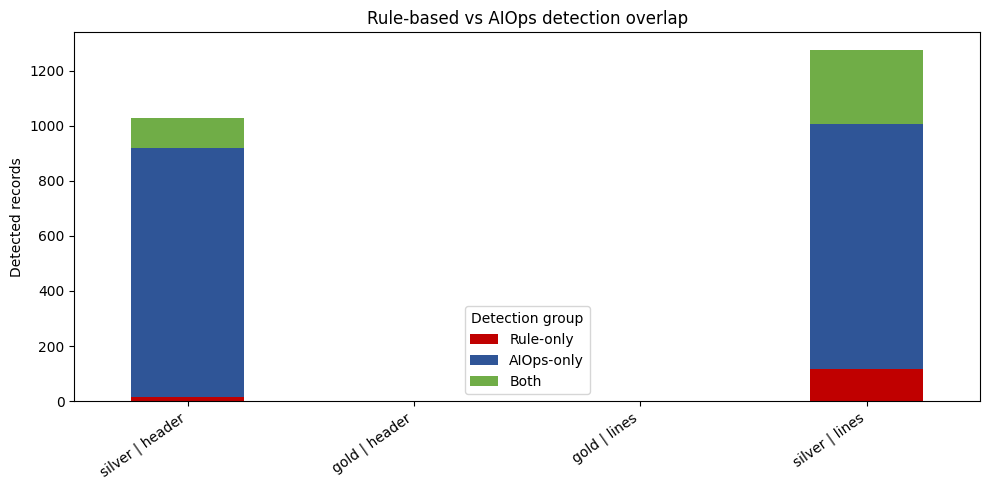

In [0]:
# Overlap matrix visualization
import matplotlib.pyplot as plt

overlap_pdf = comparison_matrix.toPandas()
if overlap_pdf.empty:
    print('No overlap matrix data to plot.')
else:
    overlap_pdf['label'] = overlap_pdf['layer'] + ' | ' + overlap_pdf['dataset']
    plot_cols = ['rule_only', 'aiops_only', 'both']
    ax = overlap_pdf.set_index('label')[plot_cols].plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5),
        color=['#c00000', '#2f5597', '#70ad47'],
    )
    ax.set_xlabel('')
    ax.set_ylabel('Detected records')
    ax.set_title('Rule-based vs AIOps detection overlap')
    ax.legend(['Rule-only', 'AIOps-only', 'Both'], title='Detection group')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()


In [0]:
def read_silver_records():
    header = optional_delta(SILVER_HEADER_PATH, schema='InvoiceId string')
    lines = optional_delta(SILVER_LINES_PATH, schema='InvoiceId string, LineNumber string')

    header_records = header.select(
        F.lit('silver').alias('layer'),
        F.lit('header').alias('dataset'),
        F.col('InvoiceId').cast('string').alias('InvoiceId'),
        F.col('_source_file').cast('string').alias('SourceFile'),
        F.col('source_type').cast('string').alias('SourceType'),
        F.lit('').alias('LineNumber'),
        *[(F.col(c).cast('string') if c in header.columns else F.lit(None).cast('string')).alias(c) for c in ['OrderDate','CustomerName','ShipMode','BalanceDue','SubTotal','DiscountPercent','DiscountAmount','ShippingAmount','InvoiceTotal']],
        *[F.lit(None).cast('string').alias(c) for c in ['ProductName','ProductId','Quantity','UnitPrice','ItemSubTotal']]
    )

    line_records = lines.select(
        F.lit('silver').alias('layer'),
        F.lit('lines').alias('dataset'),
        F.col('InvoiceId').cast('string').alias('InvoiceId'),
        F.col('_source_file').cast('string').alias('SourceFile'),
        F.col('source_type').cast('string').alias('SourceType'),
        F.col('LineNumber').cast('string').alias('LineNumber'),
        *[F.lit(None).cast('string').alias(c) for c in ['OrderDate','CustomerName','ShipMode','BalanceDue','SubTotal','DiscountPercent','DiscountAmount','ShippingAmount','InvoiceTotal']],
        *[(F.col(c).cast('string') if c in lines.columns else F.lit(None).cast('string')).alias(c) for c in ['ProductName','ProductId','Quantity','UnitPrice','ItemSubTotal']]
    )
    return header_records.unionByName(line_records, allowMissingColumns=True)

silver_records = read_silver_records()

aiops_detail = (aiops.groupBy(*key_cols).agg(
    F.max('severity').alias('aiops_severity'),
    F.max('detector_id').alias('aiops_detector_id'),
    F.max('model_name').alias('model_name'),
    F.max('model_version').alias('model_version'),
    F.max('anomaly_score').alias('anomaly_score'),
    F.max('threshold').alias('threshold'),
    F.concat_ws(' | ', F.sort_array(F.collect_set('dq_reason'))).alias('aiops_reason'),
))

rule_detail = (rule.groupBy(*key_cols).agg(
    F.concat_ws(', ', F.sort_array(F.collect_set('rule_id'))).alias('failed_rules'),
    F.concat_ws(' | ', F.sort_array(F.collect_set('dq_reason'))).alias('rule_reasons'),
    F.max('severity').alias('rule_severity'),
))

header_scores = (optional_delta(HEADER_SCORE_PATH)
    .select(F.lit('silver').alias('layer'), F.lit('header').alias('dataset'), F.col('InvoiceId').cast('string').alias('InvoiceId'), F.col('SourceFile').cast('string').alias('SourceFile'), F.lit('').alias('LineNumber'), 'anomaly_score', 'threshold', 'is_anomaly'))
line_scores = (optional_delta(LINES_SCORE_PATH)
    .select(F.lit('silver').alias('layer'), F.lit('lines').alias('dataset'), F.col('InvoiceId').cast('string').alias('InvoiceId'), F.col('SourceFile').cast('string').alias('SourceFile'), F.col('LineNumber').cast('string').alias('LineNumber'), 'anomaly_score', 'threshold', 'is_anomaly'))
all_scores = header_scores.unionByName(line_scores, allowMissingColumns=True)


## AIOps-only records that passed rules

These records were detected by the autoencoder and did not appear in the rule/GE issue log for the same record key.


In [0]:
aiops_only_passed_rules = (overlap
    .filter((F.col('layer') == 'silver') & (F.col('overlap_type') == 'aiops_only'))
    .join(aiops_detail, key_cols, 'left')
    .join(silver_records, key_cols, 'left')
    .withColumn('score_to_threshold_ratio', F.col('anomaly_score') / F.col('threshold'))
    .select('dataset', 'InvoiceId', 'LineNumber', 'SourceFile', 'SourceType',
        'aiops_detector_id', 'aiops_severity', 'anomaly_score', 'threshold', 'score_to_threshold_ratio',
        'OrderDate', 'CustomerName', 'ShipMode', 'BalanceDue', 'SubTotal', 'DiscountPercent',
        'DiscountAmount', 'ShippingAmount', 'InvoiceTotal', 'ProductName', 'ProductId', 'Quantity', 'UnitPrice', 'ItemSubTotal',
        'aiops_reason'))

aiops_only_passed_rules.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(AIOPS_ONLY_PASSED_RULES_PATH)
display(aiops_only_passed_rules.orderBy(F.desc('score_to_threshold_ratio'), 'dataset', 'InvoiceId', 'LineNumber'))


dataset,InvoiceId,LineNumber,SourceFile,SourceType,aiops_detector_id,aiops_severity,anomaly_score,threshold,score_to_threshold_ratio,OrderDate,CustomerName,ShipMode,BalanceDue,SubTotal,DiscountPercent,DiscountAmount,ShippingAmount,InvoiceTotal,ProductName,ProductId,Quantity,UnitPrice,ItemSubTotal,aiops_reason
header,20208,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,aiops_silver_header_autoencoder,ERROR,88318.234375,0.15282315015792847,577911.3588728628,2023-06-28,Elina Virtanen,STANDARD CLASS,418.30,516.41,0.200000,103.28,5.17,418.30,null,null,null,null,null,Silver header has abnormal learned feature pattern
header,20178,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,aiops_silver_header_autoencoder,ERROR,88268.8359375,0.15282315015792847,577588.1196420987,2023-11-07,Bruce Degenhardt,SECOND CLASS,1112.38,1110.93,0.050000,55.55,57.00,1112.38,null,null,null,null,null,Silver header has abnormal learned feature pattern
header,20022,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,aiops_silver_header_autoencoder,ERROR,88109.640625,0.15282315015792847,576546.4233262232,2024-06-28,Sofia Müller,SAME DAY,869.03,854.97,null,null,14.06,869.03,null,null,null,null,null,Silver header has abnormal learned feature pattern
header,20182,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,aiops_silver_header_autoencoder,ERROR,87996.7109375,0.15282315015792847,575807.4666473215,2023-06-02,Corey Catlett,SECOND CLASS,1054.70,1104.83,0.075000,82.86,32.73,1054.70,null,null,null,null,null,Silver header has abnormal learned feature pattern
header,20025,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,aiops_silver_header_autoencoder,ERROR,87927.75,0.15282315015792847,575356.2199780261,2023-07-20,Mikko Laine,SECOND CLASS,6572.39,6535.55,0.000000,0.00,36.84,6572.39,null,null,null,null,null,Silver header has abnormal learned feature pattern
lines,27720,1,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Carol%2520Adams_27720.pdf.ocr.json,json,aiops_silver_lines_autoencoder,ERROR,12.309307098388672,8.352589793503284E-4,14737.114359384626,null,null,null,null,null,null,null,null,null,"Samsung Smart Phone, VoIP",TEC-PH-5841,11,6998.64,76985.04,Silver line has abnormal learned feature pattern
lines,14070,1,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Odella%2520Nelson_14070.pdf.ocr.json,json,aiops_silver_lines_autoencoder,ERROR,3.8268730640411377,8.352589793503284E-4,4581.66048932238,null,null,null,null,null,null,null,null,null,"SAFCO Executive Leather Armchair, Black",FUR-CH-5774,11,4544.10,49985.10,Silver line has abnormal learned feature pattern
lines,27407,1,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Dean%2520percer_27407.pdf.ocr.json,json,aiops_silver_lines_autoencoder,ERROR,3.6903128623962402,8.352589793503284E-4,4418.166046256213,null,null,null,null,null,null,null,null,null,"Nokia Smart Phone, Cordless",TEC-PH-5354,9,5725.35,51528.15,Silver line has abnormal learned feature pattern
header,20063,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,aiops_silver_header_autoencoder,ERROR,514.570556640625,0.15282315015792847,3367.098218488916,2024-09-24,Mikko Laine,FIRST CLASS,1975.98,1931.38,0.000000,0.00,44.60,1975.98,null,null,null,null,null,Silver header has abnormal learned feature pattern
lines,12378,1,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Gene%2520Hale_12378.pdf.ocr.json,json,aiops_silver_lines_autoencoder,ERROR,2.7818663120269775,8.352589793503284E-4,3330.5434371872743,null,null,null,null,null,null,null,null,null,"Tenex Lockers, Single Width",OFF-ST-6263,14,2858.52,40019.28,Silver line has abnormal learned feature pattern


## Rule-only records not emphasized by AIOps

These records failed deterministic rules, but the AIOps detector did not flag the same record key as anomalous.


In [0]:
rule_only_not_emphasized = (overlap
    .filter((F.col('layer') == 'silver') & (F.col('overlap_type') == 'rule_only'))
    .join(rule_detail, key_cols, 'left')
    .join(all_scores, key_cols, 'left')
    .join(silver_records, key_cols, 'left')
    .withColumn('score_to_threshold_ratio', F.col('anomaly_score') / F.col('threshold'))
    .select('dataset', 'InvoiceId', 'LineNumber', 'SourceFile', 'SourceType',
        'rule_severity', 'failed_rules', 'rule_reasons',
        'anomaly_score', 'threshold', 'score_to_threshold_ratio', 'is_anomaly',
        'OrderDate', 'CustomerName', 'ShipMode', 'BalanceDue', 'SubTotal', 'DiscountPercent',
        'DiscountAmount', 'ShippingAmount', 'InvoiceTotal', 'ProductName', 'ProductId', 'Quantity', 'UnitPrice', 'ItemSubTotal'))

rule_only_not_emphasized.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(RULE_ONLY_NOT_EMPHASIZED_PATH)
display(rule_only_not_emphasized.orderBy('dataset', 'InvoiceId', 'LineNumber'))


dataset,InvoiceId,LineNumber,SourceFile,SourceType,rule_severity,failed_rules,rule_reasons,anomaly_score,threshold,score_to_threshold_ratio,is_anomaly,OrderDate,CustomerName,ShipMode,BalanceDue,SubTotal,DiscountPercent,DiscountAmount,ShippingAmount,InvoiceTotal,ProductName,ProductId,Quantity,UnitPrice,ItemSubTotal
header,null,,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Aaron%2520Bergman_36260.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Aaron%2520Hawkins_38461.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Adam%2520Shillingsburg_40952.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Alan%2520Dominguez_41032.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Alan%2520Shonely_37511.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Aleksandra%2520Gannaway_33912.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Amy%2520Hunt_37363.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Anna%2520Andreadi_39301.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
header,null,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Anne%2520McFarland_35501.pdf.ocr.json,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


## Why AIOps-only records were anomalous

For every AIOps-only record, this table reads the feature-contribution artifact produced by `aiops_score_silver.ipynb` and filters it to records that passed rules. Higher contribution means that feature was reconstructed poorly by the autoencoder and pushed the record above the threshold.


In [0]:
aiops_feature_contributions = optional_delta(AIOPS_FEATURE_CONTRIBUTION_PATH, FEATURE_CONTRIBUTION_SCHEMA)

aiops_only_keys = (overlap
    .filter((F.col('layer') == 'silver') & (F.col('overlap_type') == 'aiops_only'))
    .select(*key_cols)
    .dropDuplicates())

aiops_anomaly_explanations = (aiops_feature_contributions
    .withColumn('LineNumber', F.when(F.col('dataset') == 'header', F.lit('')).otherwise(F.coalesce(F.col('LineNumber').cast('string'), F.lit(''))))
    .join(aiops_only_keys, key_cols, 'inner')
    .select(
        'dataset', 'InvoiceId', 'LineNumber', 'SourceFile', 'SourceType',
        'model_name', 'model_version', 'score_run_id', 'anomaly_score', 'threshold',
        'feature_name', 'feature_value', 'training_mean', 'training_std',
        'standardized_value', 'reconstruction_value', 'feature_contribution',
        'contribution_share', 'contribution_rank'
    ))

aiops_anomaly_explanations.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(AIOPS_ANOMALY_EXPLANATION_PATH)
display(aiops_anomaly_explanations.orderBy('dataset', 'InvoiceId', 'LineNumber', 'contribution_rank'))


dataset,InvoiceId,LineNumber,SourceFile,SourceType,model_name,model_version,score_run_id,anomaly_score,threshold,feature_name,feature_value,training_mean,training_std,standardized_value,reconstruction_value,feature_contribution,contribution_share,contribution_rank
header,10052,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Jill%2520Matthias_10052.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.6058819890022278,0.15282315015792847,stddev_line_subtotal,0.0,1140.37646484375,1156.0745849609375,-0.9864211678504944,1.812455415725708,7.833709716796875,0.4309810400009155,1
header,10052,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Jill%2520Matthias_10052.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.6058819890022278,0.15282315015792847,avg_unit_price,849.7999877929688,245.14303588867188,174.40896606445312,3.4668915271759033,1.672248125076294,3.2207448482513428,0.17719317972660065,2
header,10052,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Jill%2520Matthias_10052.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.6058819890022278,0.15282315015792847,avg_line_amount,4249.0,1109.964599609375,985.9457397460938,3.183781147003174,2.062854766845703,1.2564759254455566,0.06912654638290405,3
header,10052,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Jill%2520Matthias_10052.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.6058819890022278,0.15282315015792847,source_type_code,2.0,1.0,1.0,1.0,0.00888168066740036,0.9823154807090759,0.054043278098106384,4
header,10052,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Jill%2520Matthias_10052.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.6058819890022278,0.15282315015792847,avg_quantity,5.0,4.488586902618408,1.3574048280715942,0.37675797939300537,-0.4794566035270691,0.7331033945083618,0.04033257067203522,5
header,10214,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Rick%2520Reed_10214.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.9363434910774231,0.15282315015792847,stddev_line_subtotal,0.0,1140.37646484375,1156.0745849609375,-0.9864211678504944,2.109379768371582,9.583983421325684,0.34118473529815674,1
header,10214,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Rick%2520Reed_10214.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.9363434910774231,0.15282315015792847,ship_mode_code,75.0,329.72955322265625,173.6450958251953,-1.4669550657272339,0.5770542621612549,4.177973747253418,0.14873366057872772,2
header,10214,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Rick%2520Reed_10214.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.9363434910774231,0.15282315015792847,avg_quantity,5.0,4.488586902618408,1.3574048280715942,0.37675797939300537,-1.2147307395935059,2.532836437225342,0.09016763418912888,3
header,10214,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Rick%2520Reed_10214.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.9363434910774231,0.15282315015792847,abs_header_total_diff,4.547473508864641E-13,1.6167010221876388E-13,3.441328981761832E-13,0.8516397476196289,-0.6988343596458435,2.403970241546631,0.08558006584644318,4
header,10214,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Rick%2520Reed_10214.pdf.ocr.json,json,silver_header_autoencoder,v1,20260425113452,0.9363434910774231,0.15282315015792847,avg_unit_price,848.3200073242188,245.14303588867188,174.40896606445312,3.4584059715270996,2.15690279006958,1.6939104795455933,0.06030231714248657,5


## AIOps-only severity and source-type coverage


In [0]:
aiops_only_severity_counts = (aiops_only_passed_rules
    .withColumn('aiops_severity', F.coalesce(F.col('aiops_severity'), F.lit('unknown')))
    .groupBy('dataset', 'aiops_severity')
    .agg(
        F.count('*').alias('aiops_only_records'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.avg('anomaly_score').alias('avg_anomaly_score'),
        F.max('anomaly_score').alias('max_anomaly_score'),
        F.avg('score_to_threshold_ratio').alias('avg_score_to_threshold_ratio'),
    )
    .orderBy('dataset', F.desc('aiops_only_records')))

aiops_only_source_type_counts = (aiops_only_passed_rules
    .withColumn('SourceType', F.coalesce(F.col('SourceType'), F.lit('unknown')))
    .groupBy('dataset', 'SourceType')
    .agg(
        F.count('*').alias('aiops_only_records'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.avg('anomaly_score').alias('avg_anomaly_score'),
        F.max('anomaly_score').alias('max_anomaly_score'),
    )
    .orderBy('dataset', F.desc('aiops_only_records')))


display(aiops_only_severity_counts)
display(aiops_only_source_type_counts)


dataset,aiops_severity,aiops_only_records,affected_invoices,avg_anomaly_score,max_anomaly_score,avg_score_to_threshold_ratio
header,ERROR,769,769,578.2345571482484,88318.234375,3783.6843210645566
header,WARNING,119,119,0.19521149654849237,0.2284044772386551,1.2773686208323771
header,unknown,15,0,null,null,null
lines,ERROR,867,867,0.11378117541206792,12.309307098388672,136.22263061519902
lines,unknown,15,0,null,null,null
lines,WARNING,8,7,9.917055213009007E-4,0.001168906455859542,1.1873030351284073


dataset,SourceType,aiops_only_records,affected_invoices,avg_anomaly_score,max_anomaly_score
header,json,842,842,3.002048054227778,111.46623992919922
header,csv,46,46,9612.127829422445,88318.234375
header,unknown,15,0,null,null
lines,json,819,819,0.12025350428235254,12.309307098388672
lines,csv,56,53,0.003010584271188626,0.0063933515921235085
lines,unknown,15,0,null,null


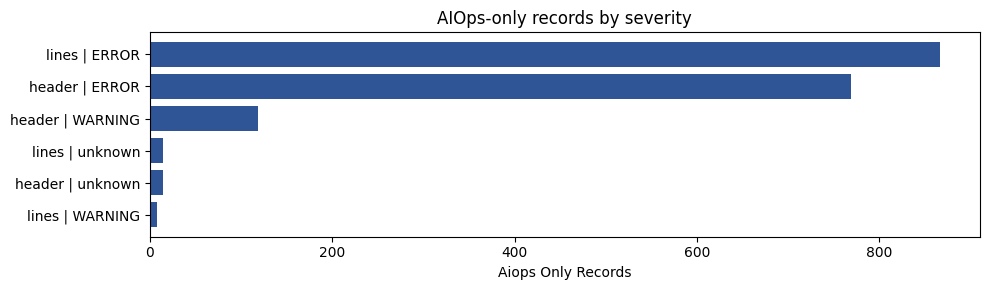

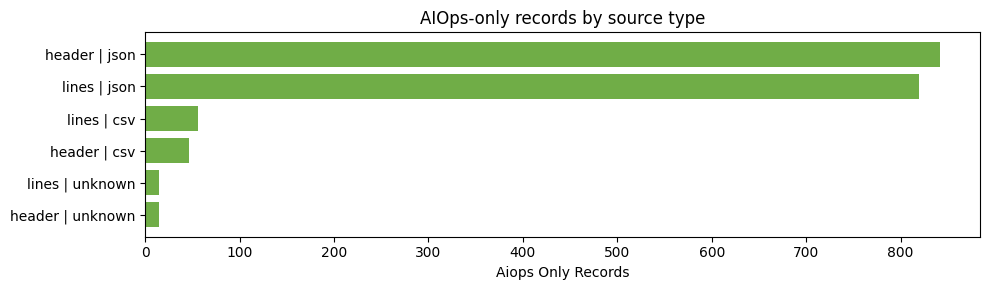

In [0]:
import matplotlib.pyplot as plt

def plot_barh(pdf, x_col, y_col, title, color='#4472c4'):
    if pdf.empty:
        print(f'No data to plot: {title}')
        return
    pdf = pdf.sort_values(x_col, ascending=True)
    fig_height = max(3, 0.35 * len(pdf))
    plt.figure(figsize=(10, fig_height))
    plt.barh(pdf[y_col], pdf[x_col], color=color)
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel('')
    plt.title(title)
    plt.tight_layout()
    plt.show()

severity_pdf = aiops_only_severity_counts.toPandas()
severity_pdf['label'] = severity_pdf['dataset'] + ' | ' + severity_pdf['aiops_severity']
plot_barh(severity_pdf, 'aiops_only_records', 'label', 'AIOps-only records by severity', '#2f5597')

source_type_pdf = aiops_only_source_type_counts.toPandas()
source_type_pdf['label'] = source_type_pdf['dataset'] + ' | ' + source_type_pdf['SourceType']
plot_barh(source_type_pdf, 'aiops_only_records', 'label', 'AIOps-only records by source type', '#70ad47')


## Both-detected severity and error agreement

This section checks whether Rule-based and AIOps assign the same severity for records detected by both approaches. It also summarizes which predefined rule error types appear in the BOTH group for header and lines.


In [0]:
both_detected_keys = (overlap
    .filter((F.col('layer') == 'silver') & (F.col('dataset').isin('header', 'lines')) & (F.col('overlap_type') == 'both'))
    .select(*key_cols)
    .dropDuplicates())

both_detected_detail = (both_detected_keys
    .join(rule_detail, key_cols, 'left')
    .join(aiops_detail, key_cols, 'left')
    .join(silver_records, key_cols, 'left')
    .withColumn('rule_severity', F.coalesce(F.col('rule_severity'), F.lit('unknown')))
    .withColumn('aiops_severity', F.coalesce(F.col('aiops_severity'), F.lit('unknown')))
    .withColumn(
        'severity_agreement',
        F.when(F.col('rule_severity') == F.col('aiops_severity'), F.lit('same severity'))
         .otherwise(F.lit('different severity'))
    )
    .withColumn('score_to_threshold_ratio', F.col('anomaly_score') / F.col('threshold'))
    .select(
        'dataset', 'InvoiceId', 'LineNumber', 'SourceFile', 'SourceType',
        'rule_severity', 'aiops_severity', 'severity_agreement',
        'failed_rules', 'rule_reasons',
        'aiops_detector_id', 'anomaly_score', 'threshold', 'score_to_threshold_ratio',
        'OrderDate', 'CustomerName', 'ShipMode', 'BalanceDue', 'SubTotal', 'DiscountPercent',
        'DiscountAmount', 'ShippingAmount', 'InvoiceTotal', 'ProductName', 'ProductId',
        'Quantity', 'UnitPrice', 'ItemSubTotal'
    ))

both_severity_agreement = (both_detected_detail
    .groupBy('dataset', 'rule_severity', 'aiops_severity', 'severity_agreement')
    .agg(
        F.count('*').alias('both_detected_records'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.avg('anomaly_score').alias('avg_anomaly_score'),
        F.avg('score_to_threshold_ratio').alias('avg_score_to_threshold_ratio'),
    )
    .orderBy('dataset', F.desc('both_detected_records')))

display(both_severity_agreement)
display(both_detected_detail.orderBy('dataset', 'severity_agreement', F.desc('score_to_threshold_ratio')))


dataset,rule_severity,aiops_severity,severity_agreement,both_detected_records,affected_invoices,avg_anomaly_score,avg_score_to_threshold_ratio
header,ERROR,ERROR,same severity,106,106,1.1537874000310076E29,7.549820814704286E29
header,WARNING,ERROR,different severity,1,1,3.405146345506928E21,2.228161336805338E22
lines,WARNING,ERROR,different severity,208,202,0.08575926394909263,102.67386052622497
lines,ERROR,ERROR,same severity,61,61,1.6302705716338088E12,1.951814481422093E15


dataset,InvoiceId,LineNumber,SourceFile,SourceType,rule_severity,aiops_severity,severity_agreement,failed_rules,rule_reasons,aiops_detector_id,anomaly_score,threshold,score_to_threshold_ratio,OrderDate,CustomerName,ShipMode,BalanceDue,SubTotal,DiscountPercent,DiscountAmount,ShippingAmount,InvoiceTotal,ProductName,ProductId,Quantity,UnitPrice,ItemSubTotal
header,20098,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,WARNING,ERROR,different severity,silver_header_arithmetic_subtotal_rollup,SubTotal does not reconcile to sum(ItemSubTotal),aiops_silver_header_autoencoder,3.405146345506928E21,0.15282315015792847,2.228161336805338E22,2024-10-08,Nguyen Minh Anh,STANDARD CLASS,1320.18,1498.38,0.150000,224.76,46.56,1320.18,null,null,null,null,null
header,20126,,abfss://csv-invoices@hantstorageaccount.dfs.core.windows.net/invoices_1000_items.csv,csv,ERROR,ERROR,same severity,silver_header_arithmetic_subtotal_rollup,SubTotal does not reconcile to sum(ItemSubTotal),aiops_silver_header_autoencoder,2.054250274018684E30,0.15282315015792847,1.3442009747186915E31,2023-03-17,Nguyen Minh Anh,SECOND CLASS,6015.22,6319.60,0.050000,315.98,11.60,6015.22,null,null,null,null,null
header,37936,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Anthony%2520Jacobs_37936.pdf.ocr.json,json,ERROR,ERROR,same severity,silver_header_arithmetic_total,InvoiceTotal does not reconcile with header arithmetic,aiops_silver_header_autoencoder,1.6488729659540517E30,0.15282315015792847,1.0789418777522222E31,2012-10-30,Anthony Jacobs,SECOND CLASS,7101.65,11373.31,0.400000,null,277.66,7101.65,null,null,null,null,null
header,15953,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Zuschuss%2520Carroll_15953.pdf.ocr.json,json,ERROR,ERROR,same severity,silver_header_arithmetic_total,InvoiceTotal does not reconcile with header arithmetic,aiops_silver_header_autoencoder,1.4228783377397498E30,0.15282315015792847,9.310620388791474E30,2012-09-22,Zuschuss Carroll,FIRST CLASS,17560.21,21130.37,0.200000,null,655.91,17560.21,null,null,null,null,null
header,20958,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Brendan%2520Murry_20958.pdf.ocr.json,json,ERROR,ERROR,same severity,silver_header_arithmetic_total,InvoiceTotal does not reconcile with header arithmetic,aiops_silver_header_autoencoder,1.1131339377722336E30,0.15282315015792847,7.283804427679403E30,2012-09-01,Brendan Murry,STANDARD CLASS,8864.21,12459.64,0.300000,null,142.46,8864.21,null,null,null,null,null
header,18994,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Carlos%2520Soltero_18994.pdf.ocr.json,json,ERROR,ERROR,same severity,silver_header_arithmetic_total,InvoiceTotal does not reconcile with header arithmetic,aiops_silver_header_autoencoder,8.333461907097219E29,0.15282315015792847,5.45301016140903E30,2013-01-09,Carlos Soltero,FIRST CLASS,3508.77,6468.38,0.500000,null,274.58,3508.77,null,null,null,null,null
header,8367,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Michael%2520Stewart_8367.pdf.ocr.json,json,ERROR,ERROR,same severity,silver_header_arithmetic_total,InvoiceTotal does not reconcile with header arithmetic,aiops_silver_header_autoencoder,5.242886495024062E29,0.15282315015792847,3.4306886683110697E30,2012-10-13,Michael Stewart,STANDARD CLASS,3922.53,6413.26,0.400000,null,74.57,3922.53,null,null,null,null,null
header,14984,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Denise%2520Leinenbach_14984.pdf.ocr.json,json,ERROR,ERROR,same severity,silver_header_arithmetic_total,InvoiceTotal does not reconcile with header arithmetic,aiops_silver_header_autoencoder,4.178919192546237E29,0.15282315015792847,2.7344804685858875E30,2012-08-24,Denise Leinenbach,FIRST CLASS,2418.31,4580.52,0.500000,null,128.05,2418.31,null,null,null,null,null
header,2642,,abfss://di-json-invoices@hantstorageaccount.dfs.core.windows.net/invoice_Larry%2520H

In [0]:
both_rule_error_types = (both_detected_keys
    .join(rule, key_cols, 'inner')
    .withColumn('rule_category', F.coalesce(F.col('issue_type'), F.lit('unknown')))
    .withColumn('rule_error_type', F.coalesce(F.col('rule_id'), F.col('issue_type'), F.lit('unknown')))
    .groupBy('dataset', 'rule_category', 'rule_error_type', 'severity')
    .agg(
        F.count('*').alias('rule_issue_events_in_both'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.countDistinct(F.concat_ws('||', 'InvoiceId', 'LineNumber', 'SourceFile')).alias('affected_records'),
        F.concat_ws(' | ', F.sort_array(F.collect_set('dq_reason'))).alias('rule_reasons'),
    )
    .orderBy('dataset', F.desc('rule_issue_events_in_both'), 'rule_error_type'))

display(both_rule_error_types)


dataset,rule_category,rule_error_type,severity,rule_issue_events_in_both,affected_invoices,affected_records,rule_reasons
header,header_total_diff,silver_header_arithmetic_total,ERROR,94,94,94,InvoiceTotal does not reconcile with header arithmetic
header,line_to_subtotal_diff,silver_header_arithmetic_subtotal_rollup,ERROR,11,11,11,SubTotal does not reconcile to sum(ItemSubTotal)
header,line_to_subtotal_diff,silver_header_arithmetic_subtotal_rollup,WARNING,1,1,1,SubTotal does not reconcile to sum(ItemSubTotal)
header,contract,silver_header_customer_name_present,ERROR,1,1,1,CustomerName is missing in Silver header
lines,line_subtotal_diff,silver_lines_arithmetic_subtotal,WARNING,208,202,208,Line subtotal does not match Quantity * UnitPrice
lines,contract,silver_lines_product_id_present,ERROR,31,31,31,ProductId is missing in Silver lines
lines,line_subtotal_diff,silver_lines_arithmetic_subtotal,ERROR,27,27,27,Line subtotal does not match Quantity * UnitPrice
lines,contract,silver_lines_product_name_present,ERROR,7,7,7,ProductName is missing in Silver lines


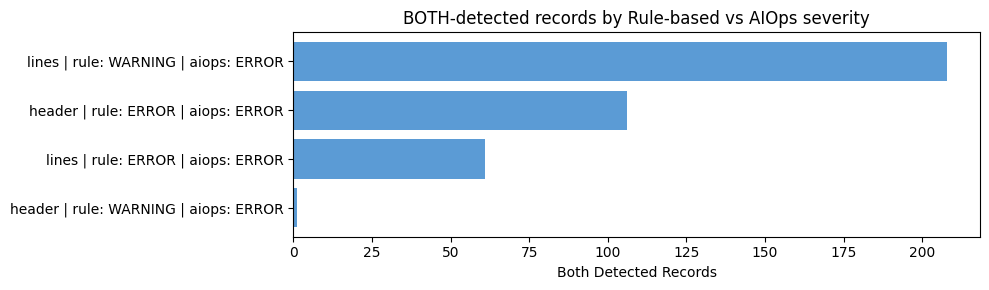

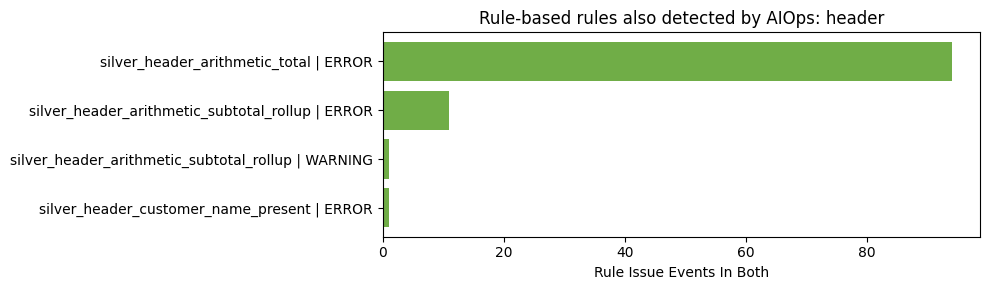

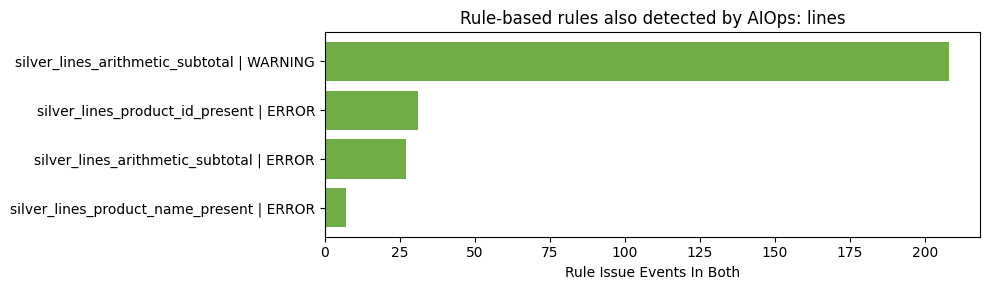

In [0]:
both_severity_pdf = both_severity_agreement.toPandas()
if both_severity_pdf.empty:
    print('No BOTH-detected severity agreement data to plot.')
else:
    both_severity_pdf['label'] = (
        both_severity_pdf['dataset'] + ' | rule: ' + both_severity_pdf['rule_severity']
        + ' | aiops: ' + both_severity_pdf['aiops_severity']
    )
    plot_barh(
        both_severity_pdf,
        'both_detected_records',
        'label',
        'BOTH-detected records by Rule-based vs AIOps severity',
        '#5b9bd5',
    )

both_error_pdf = both_rule_error_types.toPandas()
for dataset_name in ['header', 'lines']:
    ds_pdf = both_error_pdf[both_error_pdf['dataset'] == dataset_name].copy()
    if ds_pdf.empty:
        print(f'No BOTH-detected rule error types for {dataset_name}')
        continue
    ds_pdf['label'] = ds_pdf['rule_error_type'].fillna('unknown') + ' | ' + ds_pdf['severity'].fillna('unknown')
    ds_pdf = ds_pdf.sort_values('rule_issue_events_in_both', ascending=False).head(15)
    plot_barh(
        ds_pdf,
        'rule_issue_events_in_both',
        'label',
        f'Rule-based rules also detected by AIOps: {dataset_name}',
        '#70ad47',
    )


## Rule-only severity and source-type coverage


In [0]:
rule_only_severity_counts = (rule_only_not_emphasized
    .withColumn('rule_severity', F.coalesce(F.col('rule_severity'), F.lit('unknown')))
    .groupBy('dataset', 'rule_severity')
    .agg(
        F.count('*').alias('rule_only_records'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.avg('score_to_threshold_ratio').alias('avg_score_to_threshold_ratio'),
    )
    .orderBy('dataset', F.desc('rule_only_records')))

rule_only_source_type_counts = (rule_only_not_emphasized
    .withColumn('SourceType', F.coalesce(F.col('SourceType'), F.lit('unknown')))
    .groupBy('dataset', 'SourceType')
    .agg(
        F.count('*').alias('rule_only_records'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.avg('score_to_threshold_ratio').alias('avg_score_to_threshold_ratio'),
    )
    .orderBy('dataset', F.desc('rule_only_records')))

display(rule_only_severity_counts)
display(rule_only_source_type_counts)


dataset,rule_severity,rule_only_records,affected_invoices,avg_score_to_threshold_ratio
header,unknown,16,0,null
header,ERROR,1,1,0.976005646762589
lines,WARNING,100,88,0.2555170840087277
lines,unknown,16,0,null


dataset,SourceType,rule_only_records,affected_invoices,avg_score_to_threshold_ratio
header,unknown,16,0,null
header,csv,1,1,0.976005646762589
lines,csv,100,88,0.2555170840087278
lines,unknown,16,0,null


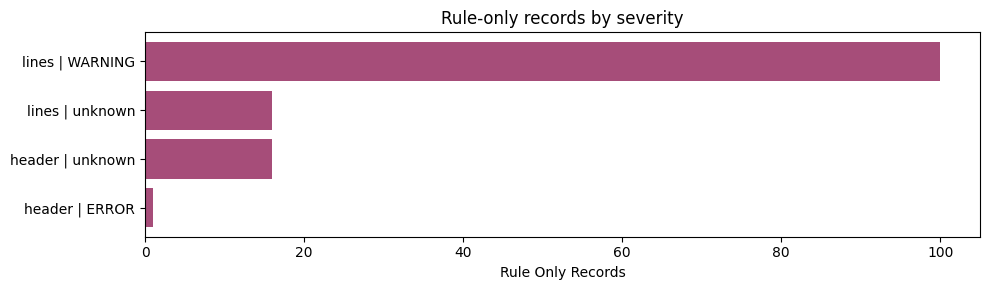

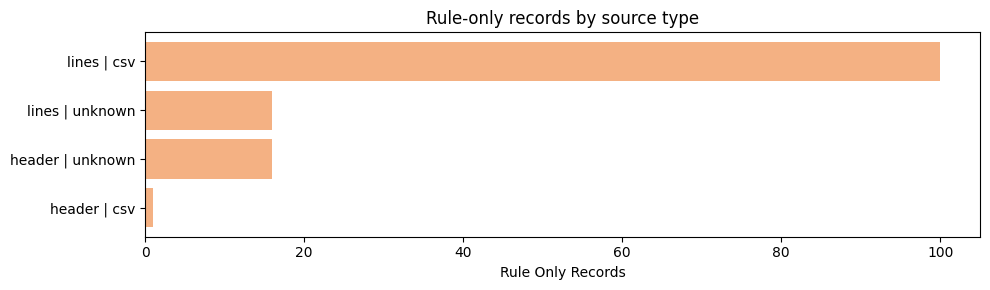

In [0]:
rule_severity_pdf = rule_only_severity_counts.toPandas()
rule_severity_pdf['label'] = rule_severity_pdf['dataset'] + ' | ' + rule_severity_pdf['rule_severity']
plot_barh(rule_severity_pdf, 'rule_only_records', 'label', 'Rule-only records by severity', '#a64d79')

rule_source_type_pdf = rule_only_source_type_counts.toPandas()
rule_source_type_pdf['label'] = rule_source_type_pdf['dataset'] + ' | ' + rule_source_type_pdf['SourceType']
plot_barh(rule_source_type_pdf, 'rule_only_records', 'label', 'Rule-only records by source type', '#f4b183')


## Rule-based error types for header and lines

This section shows which predefined rule/check categories were responsible for deterministic detections. It is the rule-based counterpart to the AIOps feature-pattern analysis.


In [0]:
rule_error_type_counts = (rule
    .filter((F.col('layer') == 'silver') & (F.col('dataset').isin('header', 'lines')))
    .withColumn('rule_category', F.coalesce(F.col('issue_type'), F.lit('unknown')))
    .withColumn('rule_error_type', F.coalesce(F.col('rule_id'), F.col('issue_type'), F.lit('unknown')))
    .groupBy('dataset', 'rule_category', 'rule_error_type', 'severity')
    .agg(
        F.count('*').alias('rule_issue_events'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.countDistinct('SourceFile').alias('affected_source_files'),
        F.concat_ws(' | ', F.sort_array(F.collect_set('dq_reason'))).alias('rule_reasons'),
    )
    .orderBy('dataset', F.desc('rule_issue_events'), 'rule_error_type'))

display(rule_error_type_counts)


dataset,rule_category,rule_error_type,severity,rule_issue_events,affected_invoices,affected_source_files,rule_reasons
header,header_total_diff,silver_header_arithmetic_total,ERROR,94,94,88,InvoiceTotal does not reconcile with header arithmetic
header,contract,silver_header_customer_name_present,ERROR,17,1,16,CustomerName is missing in Silver header
header,entity_completeness,silver_header_has_lines,ERROR,15,0,15,Header does not have any matching lines
header,line_to_subtotal_diff,silver_header_arithmetic_subtotal_rollup,ERROR,11,11,1,SubTotal does not reconcile to sum(ItemSubTotal)
header,contract,silver_header_order_date_valid,ERROR,2,1,1,OrderDate is outside the allowed range
header,line_to_subtotal_diff,silver_header_arithmetic_subtotal_rollup,WARNING,1,1,1,SubTotal does not reconcile to sum(ItemSubTotal)
header,line_to_subtotal_diff,silver_header_arithmetic_subtotal_rollup_warning,WARNING,1,0,0,SubTotal exceeds the strict reconciliation tolerance
header,header_total_diff,silver_header_arithmetic_total_warning,WARNING,1,0,0,InvoiceTotal exceeds the strict reconciliation tolerance
header,contract,silver_header_invoice_id_present,ERROR,1,0,0,InvoiceId is missing in Silver header
header,contract,silver_header_ship_city_present_warning,WARNING,1,0,0,ShipCity is missing in Silver header


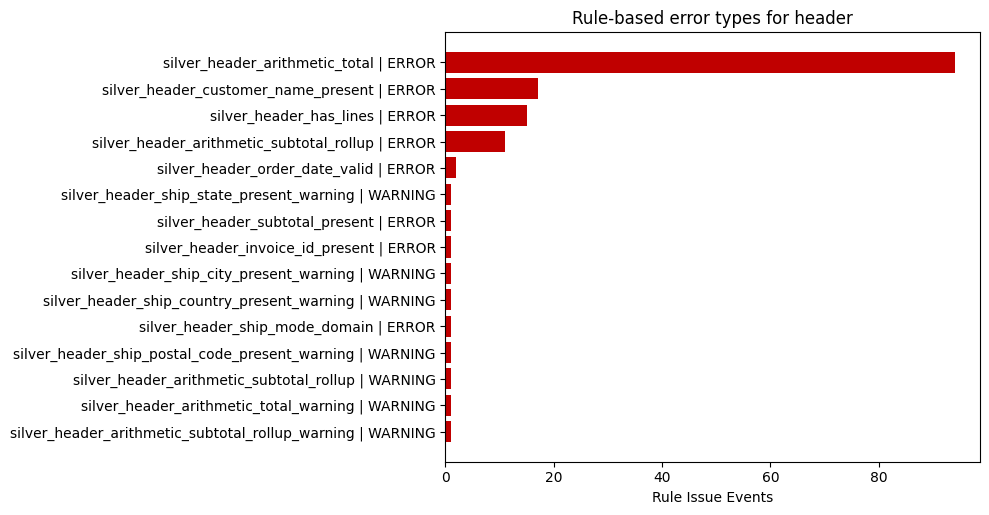

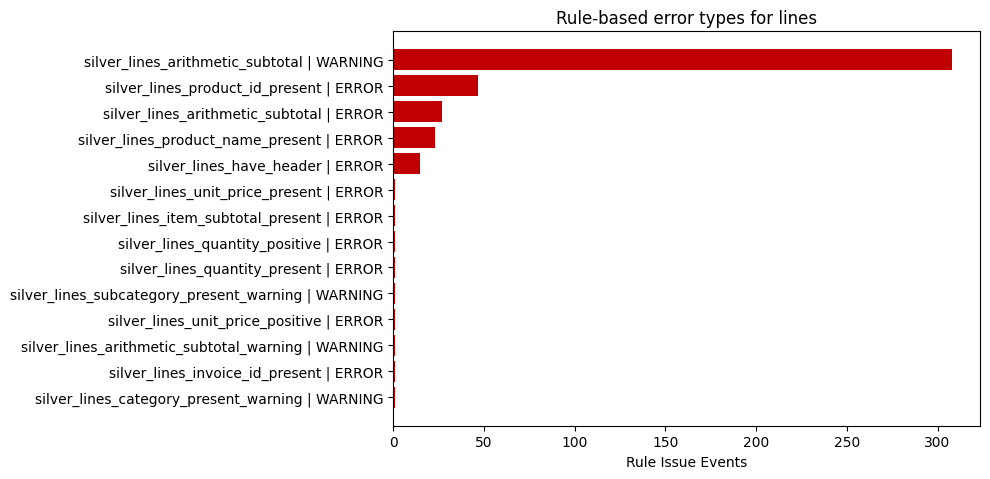

In [0]:
rule_error_pdf = rule_error_type_counts.toPandas()
for dataset_name in ['header', 'lines']:
    ds_pdf = rule_error_pdf[rule_error_pdf['dataset'] == dataset_name].copy()
    if ds_pdf.empty:
        print(f'No rule-based errors for {dataset_name}')
        continue
    ds_pdf['label'] = (
        ds_pdf['rule_error_type'].fillna('unknown')
        + ' | ' + ds_pdf['severity'].fillna('unknown')
    )
    ds_pdf = ds_pdf.sort_values('rule_issue_events', ascending=False).head(15)
    plot_barh(ds_pdf, 'rule_issue_events', 'label', f'Rule-based error types for {dataset_name}', '#c00000')


## Feature patterns explaining AIOps-only anomalies

This section counts which features most often explain AIOps-only anomalies. A feature is counted when it appears among the top reconstructed-error contributors for an AIOps-only record that passed rule-based validation.


In [0]:
TOP_FEATURE_RANK = 3

aiops_feature_pattern_counts = (aiops_anomaly_explanations
    .filter(F.col('contribution_rank') <= TOP_FEATURE_RANK)
    .groupBy('dataset', 'feature_name')
    .agg(
        F.count('*').alias('top_feature_contribution_events'),
        F.countDistinct('InvoiceId').alias('affected_invoices'),
        F.countDistinct(F.concat_ws('||', 'InvoiceId', 'LineNumber', 'SourceFile')).alias('affected_records'),
        F.avg('feature_contribution').alias('avg_feature_contribution'),
        F.avg('contribution_share').alias('avg_contribution_share'),
        F.max('contribution_share').alias('max_contribution_share'),
    )
    .orderBy('dataset', F.desc('affected_records'), F.desc('avg_contribution_share')))

display(aiops_feature_pattern_counts)


dataset,feature_name,top_feature_contribution_events,affected_invoices,affected_records,avg_feature_contribution,avg_contribution_share,max_contribution_share
header,stddev_line_subtotal,737,737,737,31.828548918585604,0.3226222576778205,0.5913227796554565
header,avg_unit_price,412,412,412,91.72779636911469,0.20224047198132114,0.7163503170013428
header,missing_financial_field_count,381,381,381,3.9112240597019046,0.37531821904923973,0.8661530613899231
header,avg_line_amount,299,299,299,135.35417988231052,0.21162599131985127,0.5509328246116638
header,source_type_code,207,207,207,0.9776203528694485,0.13686325771797106,0.20920732617378235
header,ShippingAmount,187,187,187,83.32799946170121,0.20661798757774866,0.5627341866493225
header,avg_quantity,176,176,176,72786.78882189417,0.16382717742288316,0.9688974618911743
header,ship_mode_code,176,176,176,72.18974432984197,0.1610202315707945,0.5769787430763245
header,shipping_ratio,16,16,16,0.38182107731699944,0.05829844856634736,0.08761600404977798
header,abs_header_total_diff,13,13,13,4076.752522317263,0.09887329718241325,0.43775030970573425


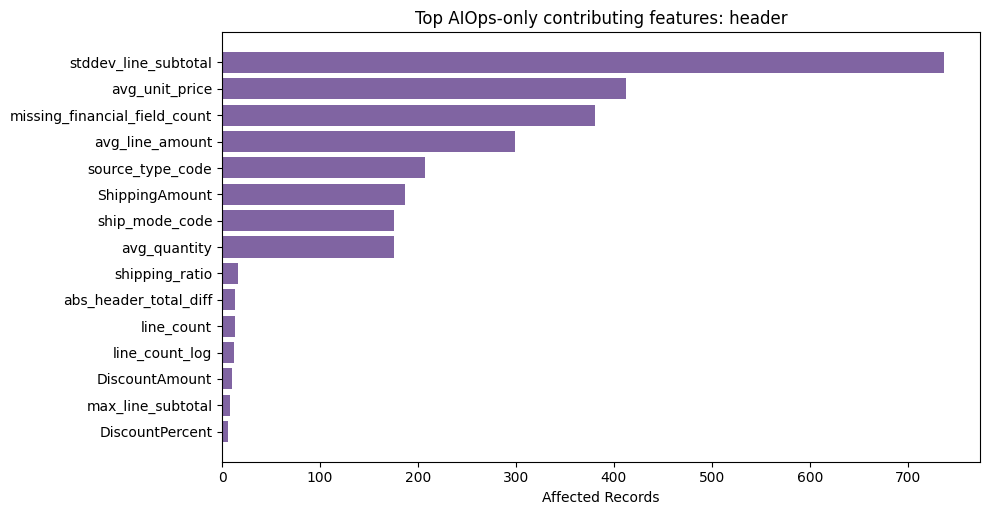

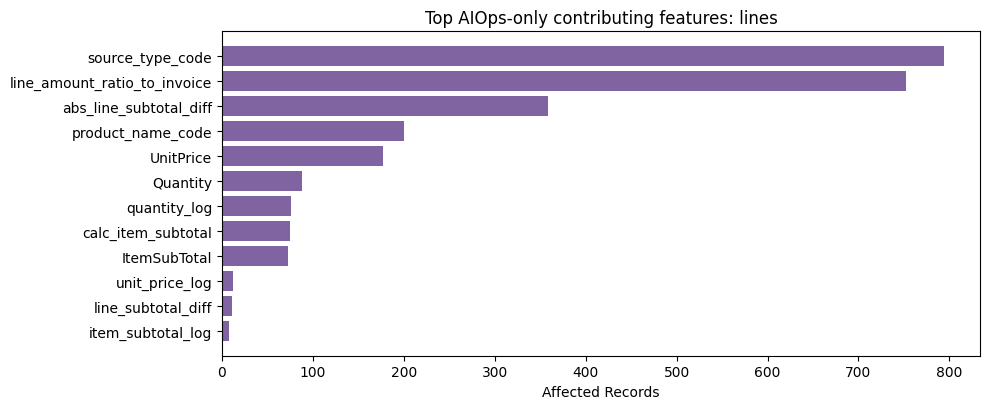

In [0]:
feature_pattern_pdf = aiops_feature_pattern_counts.toPandas()
for dataset_name in ['header', 'lines']:
    ds_pdf = feature_pattern_pdf[feature_pattern_pdf['dataset'] == dataset_name].copy()
    if ds_pdf.empty:
        print(f'No AIOps-only feature explanations for {dataset_name}')
        continue
    ds_pdf = ds_pdf.sort_values('affected_records', ascending=False).head(15)
    plot_barh(ds_pdf, 'affected_records', 'feature_name', f'Top AIOps-only contributing features: {dataset_name}', '#8064a2')


## Silver runtime comparison

This section compares Silver-only Great Expectations runtime with Silver AIOps scoring runtime. 


In [0]:
GE_RUNTIME_SCHEMA = T.StructType([
    T.StructField('layer', T.StringType(), True),
    T.StructField('suite_name', T.StringType(), True),
    T.StructField('run_id', T.StringType(), True),
    T.StructField('started_at', T.TimestampType(), True),
    T.StructField('ended_at', T.TimestampType(), True),
    T.StructField('runtime_seconds', T.DoubleType(), True),
    T.StructField('rows_evaluated', T.LongType(), True),
    T.StructField('rows_per_second', T.DoubleType(), True),
    T.StructField('evaluated_expectations', T.LongType(), True),
    T.StructField('successful_expectations', T.LongType(), True),
    T.StructField('failed_expectations', T.LongType(), True),
    T.StructField('expectation_success_percent', T.DoubleType(), True),
    T.StructField('validation_success', T.BooleanType(), True),
    T.StructField('recorded_at', T.TimestampType(), True),
])

AIOPS_RUNTIME_SCHEMA = T.StructType([
    T.StructField('layer', T.StringType(), True),
    T.StructField('operation_name', T.StringType(), True),
    T.StructField('run_id', T.StringType(), True),
    T.StructField('model_version', T.StringType(), True),
    T.StructField('started_at', T.TimestampType(), True),
    T.StructField('ended_at', T.TimestampType(), True),
    T.StructField('runtime_seconds', T.DoubleType(), True),
    T.StructField('rows_evaluated', T.LongType(), True),
    T.StructField('anomalies_detected', T.LongType(), True),
    T.StructField('records_per_second', T.DoubleType(), True),
    T.StructField('recorded_at', T.TimestampType(), True),
])

ge_runtime = (optional_delta(GE_RUNTIME_METRICS_PATH, GE_RUNTIME_SCHEMA)
    .filter(F.lower(F.col('layer')) == 'silver')
    .select(
        F.lit('GE').alias('approach'),
        F.col('run_id'),
        F.col('suite_name').alias('operation_name'),
        F.lit(None).cast('string').alias('model_version'),
        'started_at', 'ended_at', 'runtime_seconds', 'rows_evaluated',
        F.col('rows_per_second').alias('records_per_second'),
        'evaluated_expectations', 'successful_expectations', 'failed_expectations',
        'expectation_success_percent', 'validation_success',
        F.lit(None).cast('long').alias('anomalies_detected'),
        'recorded_at'
    ))

aiops_runtime = (optional_delta(AIOPS_RUNTIME_METRICS_PATH, AIOPS_RUNTIME_SCHEMA)
    .filter((F.lower(F.col('layer')) == 'silver') & (F.col('operation_name') == 'aiops_score_silver_end_to_end'))
    .select(
        F.lit('AIOps').alias('approach'),
        F.col('run_id'),
        F.col('operation_name'),
        F.col('model_version'),
        'started_at', 'ended_at', 'runtime_seconds', 'rows_evaluated',
        'records_per_second',
        F.lit(None).cast('long').alias('evaluated_expectations'),
        F.lit(None).cast('long').alias('successful_expectations'),
        F.lit(None).cast('long').alias('failed_expectations'),
        F.lit(None).cast('double').alias('expectation_success_percent'),
        F.lit(None).cast('boolean').alias('validation_success'),
        'anomalies_detected',
        'recorded_at'
    ))

silver_runtime_detail = (ge_runtime.unionByName(aiops_runtime, allowMissingColumns=True)
    .withColumn('comparison_run_id', F.lit(RUN_ID)))

silver_runtime_comparison = (silver_runtime_detail
    .groupBy('approach', 'run_id')
    .agg(
        F.min('started_at').alias('started_at'),
        F.max('ended_at').alias('ended_at'),
        F.sum('runtime_seconds').alias('total_runtime_seconds'),
        F.sum('rows_evaluated').alias('rows_evaluated'),
        F.sum('anomalies_detected').alias('anomalies_detected'),
        F.sum('evaluated_expectations').alias('evaluated_expectations'),
        F.sum('failed_expectations').alias('failed_expectations'),
        F.count('*').alias('runtime_rows'),
    )
    .withColumn('records_per_second', F.when(F.col('total_runtime_seconds') > 0, F.col('rows_evaluated') / F.col('total_runtime_seconds')))
    .withColumn('comparison_run_id', F.lit(RUN_ID)))

silver_runtime_detail.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(SILVER_RUNTIME_DETAIL_PATH)
silver_runtime_comparison.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(SILVER_RUNTIME_COMPARISON_PATH)

silver_runtime_thesis_table = (silver_runtime_detail
    .groupBy('approach')
    .agg(
        F.round(F.sum('runtime_seconds'), 3).alias('Runtime'),
        F.sum('rows_evaluated').cast('long').alias('Rows evaluated'),
    )
    .withColumn('Throughput', F.round(F.col('Rows evaluated') / F.col('Runtime'), 3))
    .select(
        F.col('approach').alias('Approach'),
        'Runtime',
        'Rows evaluated',
        'Throughput',
    )
    .orderBy('Approach'))

display(silver_runtime_thesis_table)


Approach,Runtime,Rows evaluated,Throughput
AIOps,39.404,3252,82.53
GE,853.439,8858,10.379


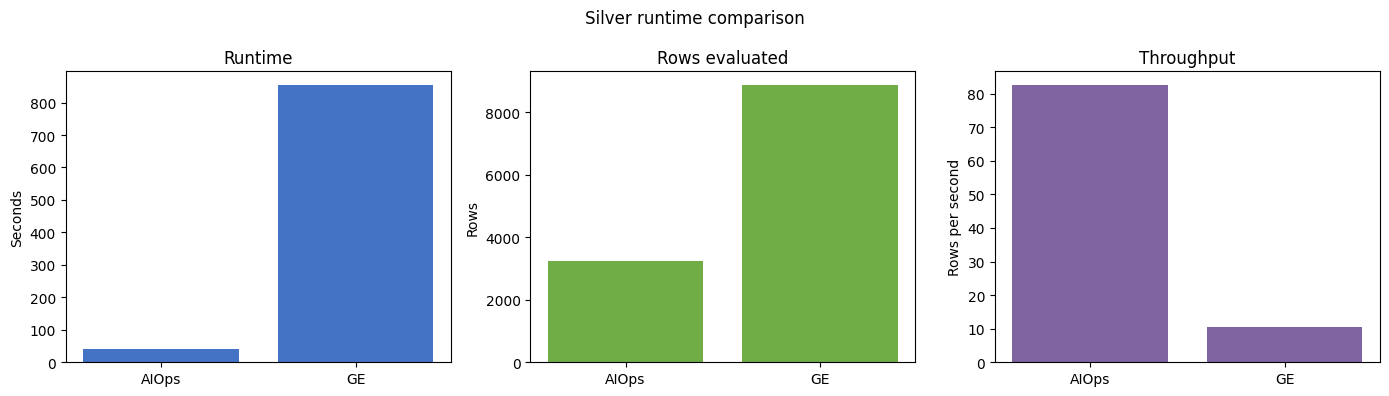

In [0]:
# Silver runtime thesis table visualization
runtime_pdf = silver_runtime_thesis_table.toPandas()
if runtime_pdf.empty:
    print('No Silver runtime data to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].bar(runtime_pdf['Approach'], runtime_pdf['Runtime'], color='#4472c4')
    axes[0].set_title('Runtime')
    axes[0].set_ylabel('Seconds')

    axes[1].bar(runtime_pdf['Approach'], runtime_pdf['Rows evaluated'], color='#70ad47')
    axes[1].set_title('Rows evaluated')
    axes[1].set_ylabel('Rows')

    axes[2].bar(runtime_pdf['Approach'], runtime_pdf['Throughput'], color='#8064a2')
    axes[2].set_title('Throughput')
    axes[2].set_ylabel('Rows per second')

    for ax in axes:
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)

    fig.suptitle('Silver runtime comparison')
    plt.tight_layout()
    plt.show()


## Summary

In [0]:
summary = (all_detections.groupBy('detector_type','layer','dataset','severity')
    .agg(F.count('*').alias('total_issue_events'),
         F.countDistinct('InvoiceId').alias('affected_invoices'),
         F.countDistinct('rule_id').alias('distinct_rules_or_detectors'))
    .withColumn('comparison_run_id', F.lit(RUN_ID)))

summary.write.format('delta').mode('overwrite').option('overwriteSchema', 'true').save(THESIS_SUMMARY_PATH)

dbutils.jobs.taskValues.set(key='aiops_comparison_metrics_path', value=DETECTION_METRICS_PATH)
dbutils.jobs.taskValues.set(key='aiops_detection_overlap_path', value=DETECTION_OVERLAP_PATH)
dbutils.jobs.taskValues.set(key='aiops_only_passed_rules_path', value=AIOPS_ONLY_PASSED_RULES_PATH)
dbutils.jobs.taskValues.set(key='rule_only_not_emphasized_path', value=RULE_ONLY_NOT_EMPHASIZED_PATH)
dbutils.jobs.taskValues.set(key='aiops_anomaly_explanation_path', value=AIOPS_ANOMALY_EXPLANATION_PATH)
dbutils.jobs.taskValues.set(key='silver_runtime_comparison_path', value=SILVER_RUNTIME_COMPARISON_PATH)
dbutils.jobs.taskValues.set(key='silver_runtime_detail_path', value=SILVER_RUNTIME_DETAIL_PATH)
dbutils.jobs.taskValues.set(key='aiops_thesis_summary_path', value=THESIS_SUMMARY_PATH)


display(summary.orderBy('layer','dataset','detector_type','severity'))


detector_type,layer,dataset,severity,total_issue_events,affected_invoices,distinct_rules_or_detectors,comparison_run_id
rule_based,gold,header,WARNING,4,0,4,20260426125256
rule_based,gold,lines,WARNING,1,0,1,20260426125256
aiops,silver,header,ERROR,891,876,1,20260426125256
aiops,silver,header,WARNING,119,119,1,20260426125256
rule_based,silver,header,ERROR,142,107,8,20260426125256
rule_based,silver,header,WARNING,7,1,7,20260426125256
aiops,silver,lines,ERROR,1151,1110,1,20260426125256
aiops,silver,lines,WARNING,8,7,1,20260426125256
rule_based,silver,lines,ERROR,118,63,10,20260426125256
rule_based,silver,lines,WARNING,311,267,4,20260426125256
